# PerovSeek

贝叶斯优化、光谱预测与实验反馈。

Bayesian optimization, spectral prediction and experimental feedback.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display
from perovseek.bayesian import recommend
from perovseek.spectra import load_spectra, SpectralPredictor, plot_spectra

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
OUTPUT = PROJECT / "outputs"
OUTPUT.mkdir(exist_ok=True)


/Users/dengcan/Desktop/项目/文章/video_work/tools/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Matplotlib is building the font cache; this may take a moment.


## 1. 贝叶斯优化

Bayesian optimization


In [2]:
DATA_FILE = PROJECT / "data/formulations.xlsx"
formulations = pd.read_excel(DATA_FILE, sheet_name="Formulations")
bounds = pd.read_excel(DATA_FILE, sheet_name="Bounds")
TARGET = "PCE"

print("Measured formulations:", len(formulations))
display(formulations.head(4).round(3))


Measured formulations: 126


,DMF,NFM,EA,Me-4,Py3,4PADCB,4-FBSA,F3EABr,SPFBS,PCE
0,0.74,0.14,0.12,1.29,1.72,2.15,4.26,5.00,0.71,0.396
1,0.79,0.12,0.09,2.58,2.15,3.00,0.71,2.13,1.42,12.379
2,0.84,0.11,0.05,2.15,0.43,0.86,5.00,2.84,2.13,5.619
3,0.84,0.09,0.07,0.43,3.00,1.29,1.42,4.26,2.84,5.252


In [3]:
parameters = {
    "batch_size": 6,
    "seed": 42,
    "noise_sd": 2.0,
    "mc_samples": 128,
    "num_restarts": 4,
    "raw_samples": 128,
    "fit_maxiter": 40,
    "opt_maxiter": 80,
}

candidates = recommend(
    formulations, target=TARGET, bounds=bounds, **parameters
)


In [4]:
candidates.to_csv(OUTPUT / "recommended_formulations.csv", index=False)
candidate_view = candidates.set_index("candidate_id").drop(columns="PCE_std")
display(candidate_view.round(3))


,DMF,NFM,EA,Me-4,Py3,4PADCB,4-FBSA,F3EABr,SPFBS,PCE_pred
candidate_id,,,,,,,,,,
D01,0.807,0.193,0.000,0.000,0.022,0.253,0.000,4.010,0.609,18.461
D02,0.825,0.162,0.013,0.000,0.791,0.654,0.000,2.925,1.127,19.767
D03,0.781,0.119,0.099,0.839,0.760,0.059,2.539,4.682,4.177,3.850
D04,0.861,0.047,0.093,1.927,0.439,1.730,1.992,3.761,4.047,5.646
D05,0.766,0.197,0.037,0.545,1.684,2.064,1.953,2.595,3.878,9.594
D06,0.733,0.182,0.085,0.459,2.893,2.287,2.867,0.312,1.262,7.894


## 2. 高通量实验与表征

High-throughput experimentation and characterization


## 3. 预训练模型预测

Pretrained model prediction


Spectral samples: 2268


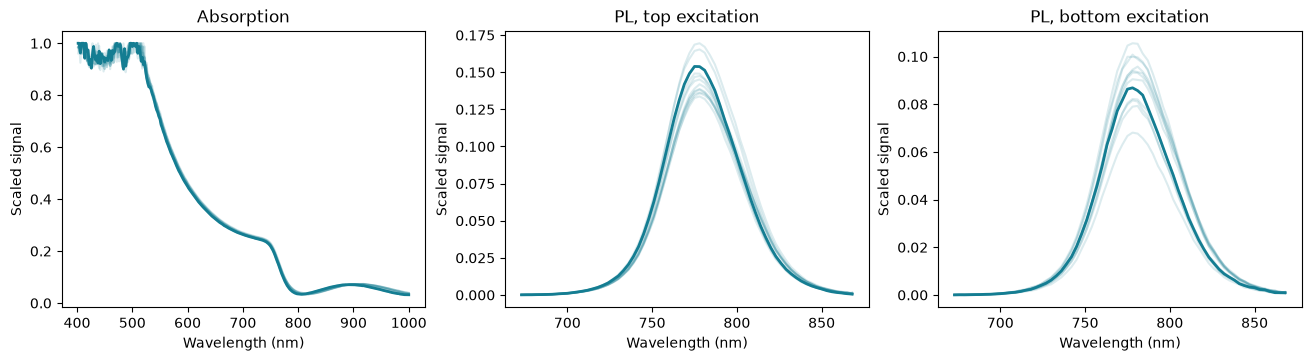

In [5]:
SPECTRA_FILE = PROJECT / "data/spectra/1.59eV_additive_data.xlsx"
spectra = load_spectra(SPECTRA_FILE, label=None)
print("Spectral samples:", len(spectra))
spectrum_figure = plot_spectra(spectra)
spectrum_figure.savefig(OUTPUT / "spectra.png", dpi=180)
display(spectrum_figure)


In [6]:
CHECKPOINT = PROJECT / "checkpoints/spectral_pce_state.pt"
predictor = SpectralPredictor(CHECKPOINT)
predictions = predictor.predict(spectra)
predictions.to_csv(OUTPUT / "spectral_predictions.csv", index=False)


In [7]:
ranked = predictions.sort_values("predicted_pce_percent", ascending=False).head(8)
ranked.to_csv(OUTPUT / "ranked_spectra.csv", index=False)
ranking_view = ranked[["sample_id", "predicted_pce_percent"]].rename(
    columns={"sample_id": "Sample", "predicted_pce_percent": "Predicted PCE (%)"}
)
display(ranking_view.style.hide(axis="index").format(precision=2))


Sample,Predicted PCE (%)
6-5-6,24.12
3-5-5,23.92
3-5-3,23.86
3-5-6,23.85
6-6-6,23.79
3-7-4,23.72
3-5-2,23.65
2-4-1,23.53


## 4. 器件验证与实验反馈

Device validation and experimental feedback


按光谱记录的来源行号读取对应的器件 PCE，核对样本编号后导出。该表展示已有光谱样本的器件记录；新推荐配方的实验结果应完成对应后再更新配方 Excel。

Read device PCE by the spectral source-row index, verify sample identifiers, and export the matched records. These are existing optical-sample records; results for newly recommended formulations must be matched before updating the formulation Excel file.


In [8]:
device_parameters = pd.read_excel(SPECTRA_FILE, sheet_name="Param")
device_rows = device_parameters.iloc[ranked["source_row"]]
assert device_rows["Unnamed: 0"].astype(str).tolist() == ranked["sample_id"].tolist()

device_results = ranked[["sample_id", "source_row"]].copy()
device_results["PCE"] = device_rows["PCE#rs1"].to_numpy()
device_results.to_csv(OUTPUT / "device_results.csv", index=False)
device_view = device_results[["sample_id", "PCE"]].rename(columns={
    "sample_id": "Sample", "PCE": "PCE (%)"
})
display(device_view.style.hide(axis="index").format(precision=2))


Sample,PCE (%)
6-5-6,22.06
3-5-5,21.28
3-5-3,21.40
3-5-6,21.48
6-6-6,21.83
3-7-4,21.61
3-5-2,21.33
2-4-1,17.93
